# CA1 : How do salary, application volume, and job visibility vary across the top 10 most-applied job titles and how do they influence each other?



---

## 1. Importing Files, Modules and Packages

### 1.1 Importing Necessary Resources

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

### 1.2 Importing Files  

In [2]:
postings1 = pd.read_csv(r"C:\Users\yanmy\PDAS\CA1 Dataset\postings1.csv",header=0,low_memory=False) 
postings2 = pd.read_csv(r"C:\Users\yanmy\PDAS\CA1 Dataset\postings2.csv",header=0)
postings3 = pd.read_csv(r"C:\Users\yanmy\PDAS\CA1 Dataset\postings3.csv",header=0)
postings4 = pd.read_csv(r"C:\Users\yanmy\PDAS\CA1 Dataset\postings4.csv",header=0)
postings5 = pd.read_excel(r"C:\Users\yanmy\PDAS\CA1 Dataset\postings5.xlsx",header=0)

---

---

## 2. Processing the Data

#### 2.1 EDA for Column Selcetion

##### Posting 2: Description Column
**Explanation:** Check the string length of job descriptions to see how detailed they are.  
**Reason:** To spot abnormal data — very short or very long descriptions may indicate missing or noisy data.

---

##### Posting 3: Missing Values in Key Columns
**Explanation:** Calculate the percentage of missing values in important fields like job ID, location, company ID, views, and salary.  
**Reason:** Identifies which columns are incomplete and need cleaning or imputation before analysis.

---

##### Posting 4: Missing Values and Uniqueness
**Explanation:** Measured missing values in skills, sponsorship, work type, and experience level. Also checked how many unique values exist in categorical fields.  
**Reason:** Ensures data completeness and validates that categorical fields (like work type or experience level) have consistent, limited categories.

---

These checks confirm the dataset is **clean, consistent, and reliable** before deeper analysis.  

In [3]:
#Posting 2
#Checking the description column by string length
print("String length:\n",postings2['description'].str.len().describe())

#Posting 3

#Checking the percentage of blank rows in different columns
print("\nPercentage of missing values by each column:\n",postings3[[
'job_id',
'location',	
'company_id',
'views',
'pay_period', 
'med_salary', 
'min_salary']].isnull().mean() * 100,"\n")

#Posting 4

#Checking the percentage of blank rows in different columns
print("\nPercentage of missing values by each column:\n",postings4[['skills_desc',
    'sponsored', 'work_type', 'formatted_experience_level']].isnull().mean() * 100)

#Checking uniqueness in the data
print("\nCount of unique value by each column:\n",postings4[['sponsored', 'work_type', 'formatted_experience_level']].nunique())

String length:
 count    123842.000000
mean       3766.456477
std        2146.505231
min           2.000000
25%        2176.000000
50%        3435.000000
75%        4986.000000
max       23201.000000
Name: description, dtype: float64

Percentage of missing values by each column:
 job_id         0.000000
location       0.000000
company_id     1.386366
views          1.363757
pay_period    70.873402
med_salary    94.929309
min_salary    75.944093
dtype: float64 


Percentage of missing values by each column:
 skills_desc                   98.030666
sponsored                      0.000000
work_type                      0.000000
formatted_experience_level    23.745852
dtype: float64

Count of unique value by each column:
 sponsored                     1
work_type                     7
formatted_experience_level    6
dtype: int64


#### 2.1.1 EDA Reflection

During the cleaning process, I evaluated each dataset (`postings1`–`postings5`) using summary statistics such as string length distribution, percentage of missing values, and count of unique values. Based on these, I made the following decisions:

- **Posting 1**
  - Drop columns 3 to 20 because they contained metadata or redundant information not useful for analysis.

- **Posting 2**
  - Remove the `description` column since it contained very long text strings (up to 23,201 characters) that are not needed for modeling or visualization.

- **Posting 3**
  - Drop `med_salary`, and `min_salary` because they had extremely high percentages of missing values (75–95%), making them unreliable features.

- **Posting 4**
  - Remove link-related columns (`job_posting_url`, `application_url`, `posting_domain`) as they are not relevant.
  - Drop time-related columns (`original_listed_time`, `expiry`, `closed_time`, `listed_time`) due to parsing failures.
  - Drop `skills_desc` because ~98% of values were missing.
  - Drop `sponsored` since it held only one unique value across all rows.
  - Remove `work_type` because it duplicated the information already captured in `formatted_work_type`.

- **Posting 5**
  - Drop `Easter Egg` and `Unimportant Column` as they were irrelevant to the analysis.

Finally, to verify consistency by checking the intersection of columns between `D_postings1` and `D_postings5` to ensure alignment after cleaning.

### 2.2 Deleting Unnecessary Columns

In [4]:
#Posting 1
# Slicing columns 3 to 20 as they are unnecessary
D_postings1 = postings1.drop(postings1.columns[3:21], axis=1)

##########

#Posting 2
D_postings2 = postings2.drop('description', axis=1)

##########

#Posting 3


#Most of the data is missing in 2 columns
D_postings3 = postings3.drop(columns=['med_salary','min_salary']) 


#########

#Posting 4
D_postings4 = postings4.drop(columns=[
    'original_listed_time',
    'expiry',
    'closed_time',
    'job_posting_url',
    'application_url',
    'skills_desc',
    'listed_time',
    'posting_domain',
    'sponsored',
    'work_type',
])

#########

#postings5
#dropping uncessary columns
D_postings5 = postings5.drop(columns=['Easter Egg', 'Unimportant Column'])

#checking if the columns in posting1 and posting5 are the same after cleaning
common_cols = D_postings5.columns.intersection(D_postings1.columns)
print(common_cols)

Index(['job_id', 'company_name', 'title'], dtype='object')


### 2.3 Merging Tables

In [5]:
df = (
    D_postings1.merge(D_postings2, on='job_id', how='left')
              .merge(D_postings3, on='job_id', how='left')
              .merge(D_postings4, on='job_id', how='left')
            #postings5 is left behind as it is the same with posting1
)
df.head()

,job_id,company_name,title,max_salary,pay_period,location,company_id,views,formatted_work_type,applies,remote_allowed,application_type,formatted_experience_level,currency,compensation_type
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,Full-time,2.0,NaN,ComplexOnsiteApply,NaN,USD,BASE_SALARY
1,1829192,NaN,Mental Health Therapist/Counselor,50.0,HOURLY,"Fort Collins, CO",NaN,1.0,Full-time,NaN,NaN,ComplexOnsiteApply,NaN,USD,BASE_SALARY
2,10998357,The National Exemplar,Assitant Restaurant Manager,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,Full-time,NaN,NaN,ComplexOnsiteApply,NaN,USD,BASE_SALARY
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,Full-time,NaN,NaN,ComplexOnsiteApply,NaN,USD,BASE_SALARY
4,35982263,NaN,Service Technician,80000.0,YEARLY,"Burlington, IA",NaN,3.0,Full-time,NaN,NaN,ComplexOnsiteApply,NaN,USD,BASE_SALARY


### 2.4 Filling Missing Data and Correcting Data Types

#### 2.4.1 Checking the Nature of Missing Values

In [6]:
#Checking the percentage of blank rows in different columns
print("\nPercentage of missing values by each column:\n",df[[
'job_id',
'company_name',
'title',
'max_salary',
'location',
'company_id',
'views',
'pay_period',
'formatted_work_type',
'applies',
'remote_allowed',
'application_type',
'formatted_experience_level',
'currency',
'compensation_type']].isnull().mean() * 100)

#checking how many differnt values in pay-period
print('\n',df['pay_period'].unique())
print(df['pay_period'].value_counts(dropna=False))

# Yearly lower bound (5th percentile)
yearly_lower = df.loc[df['pay_period'] == 'YEARLY', 'max_salary'].quantile(0.05)

# Hourly upper bound (95th percentile)
hourly_upper = df.loc[df['pay_period'] == 'HOURLY', 'max_salary'].quantile(0.95)

# Weekly, Biweekly, Monthly ranges
weekly_range = df.loc[df['pay_period'] == 'WEEKLY', 'max_salary'].quantile([0.05, 0.95])
biweekly_range = df.loc[df['pay_period'] == 'BIWEEKLY', 'max_salary'].quantile([0.05, 0.75])
monthly_range = df.loc[df['pay_period'] == 'MONTHLY', 'max_salary'].quantile([0.05, 0.95])

print("Yearly lower bound (5th percentile):", yearly_lower)
print("Hourly upper bound (95th percentile):", hourly_upper)
print("Weekly IQR:", weekly_range)
print("Biweekly IQR:", biweekly_range)
print("Monthly IQR:", monthly_range)


Percentage of missing values by each column:
 job_id                         0.000000
company_name                   1.387981
title                          0.000000
max_salary                    75.944093
location                       0.000000
company_id                     1.386366
views                          1.363757
pay_period                    70.873402
formatted_work_type            0.000000
applies                       81.170619
remote_allowed                87.689848
application_type               0.000000
formatted_experience_level    23.745852
currency                      70.873402
compensation_type             70.873402
dtype: float64

 ['HOURLY' 'YEARLY' nan 'MONTHLY' 'WEEKLY' 'BIWEEKLY']
pay_period
NaN         87776
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64
Yearly lower bound (5th percentile): 52000.0
Hourly upper bound (95th percentile): 85.0
Weekly IQR: 0.05    1638.4
0.95    2862.2
Name: m

#### 2.4.2 How to handle missing values?

After analyzing the percentage of missing values across columns, I applied different strategies based on the severity of missingness:

- **Columns with low percentage of missing values (< 2%)**
  - `company_name`: Filled with "Unknown" to preserve consistency.
  - `company_id`: Filled with "Unknown" as Id is different from each other.
  - `views`: Filled with "0" and cast to integer, assuming missing views indicate no recorded activity.

- **Columns with moderate percentage of missing values (~20–25%)**
  - `formatted_experience_level`: Filled with "Unknown" because of uncertainty in experience level.

- **Columns with high percentage of missing values (>70%)**
  - `max_salary`: Imputed by the **mean salary within each job title group** to ensure values doesn't affect the total value.
  - `currency`: Filled with `"USD"` as the dominant mode, standardizing salary representation.
  - `compensation_type`: Filled with `"BASE_SALARY"` as the most common compensation type.



The `pay_period` column contained a large proportion of missing values.  
To address this, I applied a rule-based imputation:
If missing and salary < 85 = `"HOURLY"`.
If missing and salary < 2100 = `"WEEKLY"`.
If missing and salary > 2100 = `"MONTHLY"`.
If missing and salary ≥ 5200 = `"YEARLY"`.
Biweekly salary very rare and so it is assume to be for very specific type of job. Very high hourly and weekly salaries will also be forced to change to yearly as it is assumed as typo error.



- **Columns with very high missingness but interpretable defaults**
  - `applies`: Filled with `0` and cast to integer, assuming missing values represent no applications.
  - `remote_allowed`: Filled with `0` and change to boolean, treating missing values as non-remote jobs.

#### 2.4.3 Handling Missing Values

In [7]:
#Column with low percentage of blank values
df['company_name'] = df['company_name'].fillna('Unknown')
df['company_id'] = df['company_id'].fillna('Unknown')
df['views'] = df['views'].fillna(0).astype(int)

#Column with moderate percentage of blank values
df['formatted_experience_level'] = df['formatted_experience_level'].fillna('Unknown')
df.head()

#Column with high percentage of blank values
# Fill max_salary by title group
df['max_salary'] = df.groupby('title')['max_salary'].transform(lambda x: x.fillna(x.mean())).round(2)

#fill pay_period based on the salary
df['pay_period'] = df.apply(
    lambda row: (
        'HOURLY' if pd.isna(row['pay_period']) and row['max_salary'] < 85 else
        'WEEKLY' if pd.isna(row['pay_period']) and row['max_salary'] >=85 and row['max_salary']<2100 else
        'MONTHLY' if pd.isna(row['pay_period']) and row['max_salary'] >= 2100 and row['max_salary']<5200 else
        'YEARLY' if pd.isna(row['pay_period']) and row['max_salary'] >= 5200 else
        'YEARLY' if row['max_salary'] >= 6000 and row['pay_period'] not in ['MONTHLY','BIWEEKLY'] else
        row['pay_period']
    ),
    axis=1
)

# Fill currency and compensation_type with mode
df['currency'] = df['currency'].fillna('USD')
df['compensation_type'] = df['compensation_type'].fillna('BASE_SALARY')

df['applies'] = df['applies'].fillna(0).astype(int)
df['remote_allowed'] = df['remote_allowed'].fillna(0).astype(bool)

---

---

## 3. Dataset Refinement for Question

### 3.1 Filtering the necessary data

** Going back to our question, we only want to focus on 10 most applied job titles. *

- Group job titles and sum total applications  
- Sort titles by application count (highest first)  
- Select the top 10 job titles  
- Filter dataset to include only those top 10 titles  
- Display the filtered dataset for further analysis

In [8]:
# Finding top 10 job titles based on total applies
title_applies = df.groupby('title')['applies'].sum().sort_values(ascending=False)

# Getting the top 10 titles
top_10_titles = title_applies.head(10).index

# Filtering the dataset to include only those top titles
df_top = df[df['title'].isin(top_10_titles)]

df_top

,job_id,company_name,title,max_salary,pay_period,location,company_id,views,formatted_work_type,applies,remote_allowed,application_type,formatted_experience_level,currency,compensation_type
22,133130219,Unknown,Software Engineer,151247.21,YEARLY,Los Angeles Metropolitan Area,Unknown,1,Full-time,0,False,ComplexOnsiteApply,Unknown,USD,BASE_SALARY
26,175485704,GOYT,Software Engineer,151247.21,YEARLY,"Denver, CO",76987056.0,273,Part-time,49,False,ComplexOnsiteApply,Unknown,USD,BASE_SALARY
30,229924287,REquipment Durable Medical Equipment and Assis...,Administrative Assistant,22394.99,YEARLY,"Woburn, MA",14773918.0,3,Part-time,0,False,ComplexOnsiteApply,Unknown,USD,BASE_SALARY
78,2234533717,Ideando Inc,Full Stack Engineer,93054.25,YEARLY,United States,69611476.0,21,Full-time,6,True,ComplexOnsiteApply,Unknown,USD,BASE_SALARY
106,3117273910,Cape Fear Commercial,Administrative Assistant,22394.99,YEARLY,"Wilmington, NC",10225354.0,23,Full-time,2,False,ComplexOnsiteApply,Unknown,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122476,3906253686,Findorff,Project Manager,83131.48,YEARLY,"Milwaukee, WI",117700.0,3,Full-time,0,False,OffsiteApply,Entry level,USD,BASE_SALARY
123205,3906257377,TriMark USA,Project Manager,83131.48,YEARLY,"Irvine, CA",150203.0,3,Full-time,0,False,OffsiteApply,Entry level,USD,BASE_SALARY
123740,3906261408,ECHELON USA,Project Manager,83131.48,YEARLY,"Brentwood, TN",98033070.0,2,Full-time,0,False,ComplexOnsiteApply,Unknown,USD,BASE_SALARY
123777,3906262087,Mindlance,Project Manager,65.00,HOURLY,"Washington, DC",47040.0,2,Contract,0,False,ComplexOnsiteApply,Mid-Senior level,USD,BASE_SALARY


### 3.2 Normalizing and Outlier Handling

#### 3.2.1 Normalizing the salary to hourly rate

Assuming a staff works 40 hours a week,
- Yearly / 2080
- Monthly / 173.33
- Weekly / 40
- Biweekly / 80
- Hourly left unchanged

In [9]:
df_top['normalized_salary_hourly'] = df_top.apply(
    lambda row: row['max_salary'] / 2080 if row['pay_period'] == 'YEARLY' else
                (row['max_salary'] / 173.33 if row['pay_period'] == 'MONTHLY' else
                (row['max_salary'] / 40 if row['pay_period'] == 'WEEKLY' else
                (row['max_salary'] / 80 if row['pay_period'] == 'BIWEEKLY' else
                row['max_salary']))),
    axis=1
)
df_top.head()

C:\Users\yanmy\AppData\Local\Temp\ipykernel_31956\1951262048.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top['normalized_salary_hourly'] = df_top.apply(


,job_id,company_name,title,max_salary,pay_period,location,company_id,views,formatted_work_type,applies,remote_allowed,application_type,formatted_experience_level,currency,compensation_type,normalized_salary_hourly
22,133130219,Unknown,Software Engineer,151247.21,YEARLY,Los Angeles Metropolitan Area,Unknown,1,Full-time,0,False,ComplexOnsiteApply,Unknown,USD,BASE_SALARY,72.715005
26,175485704,GOYT,Software Engineer,151247.21,YEARLY,"Denver, CO",76987056.0,273,Part-time,49,False,ComplexOnsiteApply,Unknown,USD,BASE_SALARY,72.715005
30,229924287,REquipment Durable Medical Equipment and Assis...,Administrative Assistant,22394.99,YEARLY,"Woburn, MA",14773918.0,3,Part-time,0,False,ComplexOnsiteApply,Unknown,USD,BASE_SALARY,10.766822
78,2234533717,Ideando Inc,Full Stack Engineer,93054.25,YEARLY,United States,69611476.0,21,Full-time,6,True,ComplexOnsiteApply,Unknown,USD,BASE_SALARY,44.737620
106,3117273910,Cape Fear Commercial,Administrative Assistant,22394.99,YEARLY,"Wilmington, NC",10225354.0,23,Full-time,2,False,ComplexOnsiteApply,Unknown,USD,BASE_SALARY,10.766822


#### 3.2.2 Why Remove Outliers?

Outliers are extreme values that distort averages and compress visualizations.  
By removing them, we:
- Ensure fair comparisons across job titles and locations  
- Improve clarity in charts (boxplots)  
- Make statistical summaries more reliable  


#### 3.2.3 Outlier Handling

In [10]:
# Define the IQR-based outlier removal lambda
#Outlier Lower = Q1 - 1.5 * IQR
#Outlier Upper = Q1 + 1.5 * IQR

iqr_filter = lambda g: (
    g[
        (g['normalized_salary_hourly'] >= g['normalized_salary_hourly'].quantile(0.25) - 
         1.0 * (g['normalized_salary_hourly'].quantile(0.75) - g['normalized_salary_hourly'].quantile(0.25))) &
        (g['normalized_salary_hourly'] <= g['normalized_salary_hourly'].quantile(0.75) + 
         1.0 * (g['normalized_salary_hourly'].quantile(0.75) - g['normalized_salary_hourly'].quantile(0.25)))
    ]
)

---

---

## 4. Graphical Analysis

### 4.1 Line Graph

#### Steps for Comparing Applies and Views by Job Title

1. **Group by Job Title**
   - Calculate the total number of applications (`applies`) for each job title.
   - Calculate the total number of views (`views`) for each job title.

2. **Align Views**
   - Reorder the views data to match the sorted order of applications.
   - This keeps both metrics aligned by job title.

3. **Plot Line Charts**
   - Plot applications and views as separate lines on the same chart.
   - Add labels, title, and legend for clarity.

4. **Improve Readability**
   - Rotate x-axis labels for better visibility.
   - Use `tight_layout()` to prevent overlap of labels and chart elements.

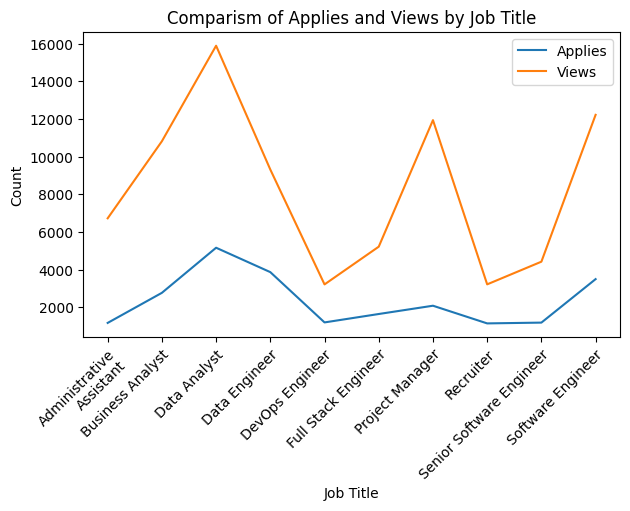

In [11]:
#Group by title and calculate total applies
applies_by_title = df_top.groupby('title')['applies'].sum()

#Group by title and calculate total views
views_by_title = df_top.groupby('title')['views'].sum().astype(int)


plt.plot(applies_by_title.index, applies_by_title.values, label='Applies')
plt.plot(views_by_title.index, views_by_title.values, label='Views')
plt.title('Comparism of Applies and Views by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45, ha='right', wrap=True) # for better visibility in X-axis
plt.tight_layout() # for better visibility in X-axis
plt.show()

#### Reflection: Applies vs Views by Job Title

This graph compares job application volume and visibility across roles.  
Key observations:
- **Views consistently exceed applications**, showing that not all interest converts to action.
- **Data Analyst** and **Software Engineer** stand out with high views and strong application volume.
- Roles like **Administrative Assistant** and **Recruiter** have lower engagement overall.
- The gap between views and applies suggests that job appeal, requirements, or application complexity may influence conversion.

This visualization helps identify which roles attract attention and which convert that attention into actual applications.

---

### 4.2 Bar Chart

#### Steps for Plotting Average Salary by Job Title

1. **Group by Job Title**
   - Calculate the mean of `normalized_salary_hourly` for each job title.
   - Round the result to 2 decimal places for readability.

2. **Sort by Salary**
   - Sort job titles in descending order based on average hourly salary.

3. **Preview Top Results**
   - Print the top 10 highest-paying job titles.

4. **Plot Bar Chart**
   - Use a vertical bar chart to visualize average salary by job title.
   - Customize with title, axis labels, rotated x-ticks, grid, and tight layout.

title
Senior Software Engineer    92.01
Software Engineer           78.13
Data Engineer               55.24
Full Stack Engineer         55.00
DevOps Engineer             49.08
Project Manager             46.11
Business Analyst            32.00
Recruiter                   28.83
Data Analyst                28.50
Administrative Assistant    17.23
Name: normalized_salary_hourly, dtype: float64


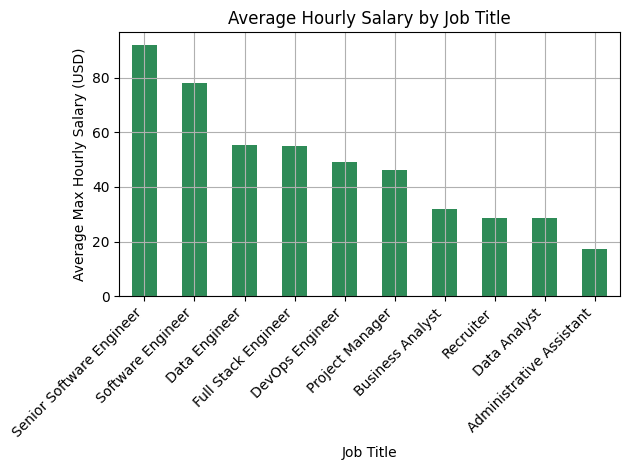

In [166]:
avg_salary_by_title = df_top.groupby('title')['normalized_salary_hourly'].mean().sort_values(ascending=False).round(2)


# Preview top results
print(avg_salary_by_title.head(10))

avg_salary_by_title.plot(kind='bar', color='seagreen')
plt.title('Average Hourly Salary by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Max Hourly Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.show()

#### Reflection: Average Hourly Salary by Job Title

This chart highlights the earning potential across roles based on average hourly salary.  
Key insights:
- **Senior Software Engineer** and **Software Engineer** lead with the highest average pay.
- Technical roles like **Data Engineer** and **Full Stack Engineer** consistently rank above business or support roles.
- **Administrative Assistant** and **Recruiter** show the lowest average salaries, reflecting market demand.

### 4.3 Boxplot

## Steps for Salary Distribution by Experience Level

1. **Remove Unknown Experience Levels**
   - Filter out rows where `formatted_experience_level` is "Unknown".

2. **Apply IQR Filter**
   - Remove outliers in `normalized_salary_hourly` within each experience level group using the IQR method.
   - Outlier is removed as we want to focus on the interquatine range. 

3. **Plot Horizontal Boxplot**
   - Visualize salary distribution across experience levels.
   - Use horizontal layout for better readability.
   - Customize flier style and layout for clarity.



C:\Users\yanmy\AppData\Local\Temp\ipykernel_31956\2380213881.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered1 = df_no_unknown.groupby('formatted_experience_level', group_keys=False).apply(iqr_filter)


<Figure size 1000x800 with 0 Axes>

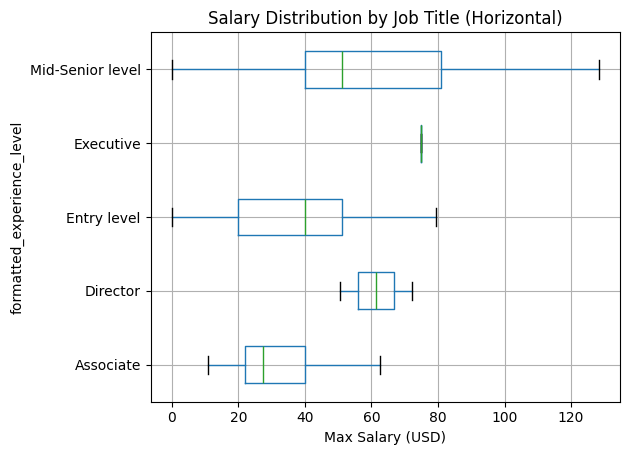

In [16]:
#Remove unknown Experience Level
df_no_unknown = df_top[df_top['formatted_experience_level'] != "Unknown"]

# Apply IQR filter to each group
df_filtered1 = df_no_unknown.groupby('formatted_experience_level', group_keys=False).apply(iqr_filter)

plt.figure(figsize=(10,8))
df_filtered1.boxplot(column='normalized_salary_hourly', by='formatted_experience_level', vert=False)

plt.title("Salary Distribution by Job Title (Horizontal)")
plt.suptitle("")
plt.xlabel("Max Salary (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Reflection: Salary Distribution Across Experience Levels

This boxplot compares salary ranges across five experience levels:

- **Executive**: Highest median and smallest spread.
- **Mid-Senior level**: Strong median with widest variability, indicating diverse roles and pay.
- **Associate**: Lowest median salary with tighter range.
- **Entry level**: Low median and wide spread.
- **Director**: Tight salary range, but high median pay.

Outliers were removed using IQR filtering to ensure fair comparison and clearer visualization.

### 4.4 Histogram

#### Steps for Plotting Overall Salary Distribution

1. **Select Salary Column**
   - Use `normalized_salary_hourly` to analyze hourly pay across all job titles.

2. **Create Histogram**
   - Plot salary distribution using 30 bins for clarity.
   - Use black edges for visual clarity.

IQR filtering is skipped because this histogram shows the **overall salary distribution**.  
Outliers are part of the real-world spread and help reveal skewness, gaps, and rare high-paying roles.  
Filtering would hide those patterns and distort the full picture.

Text(0, 0.5, 'Frequency')

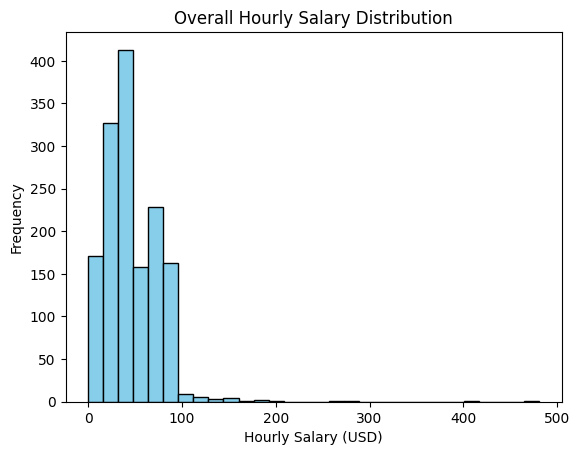

In [13]:
plt.hist(df_top['normalized_salary_hourly'], bins=30, color='skyblue', edgecolor='black')
plt.title("Overall Hourly Salary Distribution")
plt.xlabel("Hourly Salary (USD)")
plt.ylabel("Frequency")

#### Reflection: Overall Hourly Salary Distribution

This histogram shows how hourly salaries are distributed across all job postings.  
Key insights:
- Most salaries fall between **0 and 100**, indicating a concentration with the highest frequency around **40 and 50**.
- Salaries above **$100/hour** are rare, with frequency dropping sharply as pay increases.
- The distribution is **right-skewed**, suggesting a few high-paying roles influence the upper tail.

This visualization helps identify common pay ranges.

### 4.4 Pie Chart

#### Steps for Plotting Application Share by Job Title

1. **Group by Job Title**
   - Sum the total number of applications (`applies`) for each job title.

2. **Create Pie Chart**
   - Plot application share using a pie chart.
   - Each slice represents the proportion of total applications per job title.

3. **Customize Plot**
   - Add labels and percentage display (`autopct`) to show the percentage value.
   - Set figure size and title for readability.

This chart shows how application volume is distributed across job titles, highlighting the most least applied roles.

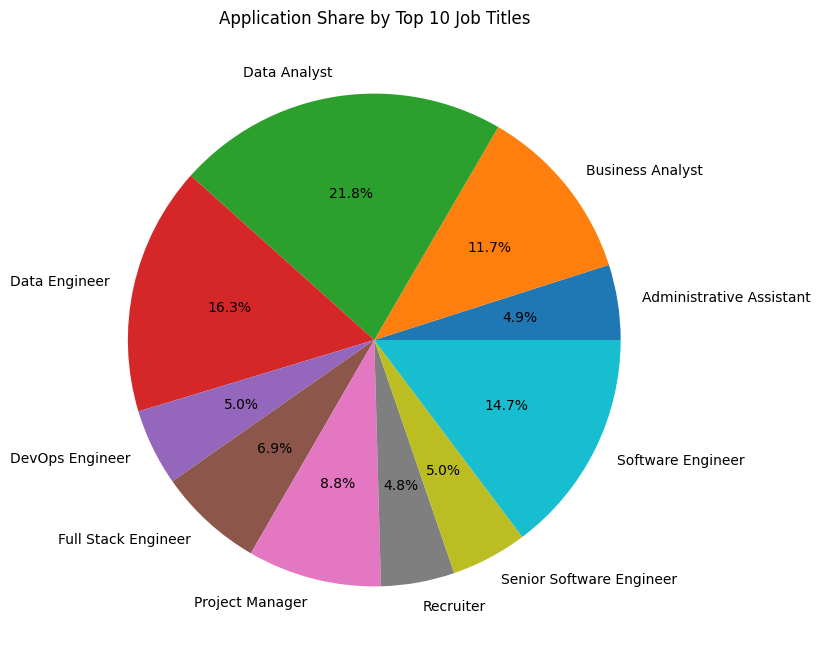

In [170]:
applies_share = df_top.groupby('title')['applies'].sum()

plt.figure(figsize=(8,8))
plt.pie(applies_share.values, labels=applies_share.index, autopct='%1.1f%%')
plt.title("Application Share by Top 10 Job Titles")
plt.show()

#### Reflection: Application Share by Job Title

This pie chart shows how applications are distributed across the top 10 job titles.  
Key insights:
- **Data Analyst** dominates with over 20% of total applications, indicating strong market interest.
- **Software Engineer** and **Data Engineer** also attract high volumes, reflecting demand for technical roles.
- Roles like **Recruiter** and **Administrative Assistant** receive fewer applications, suggesting lower applicant engagement.

This visualization highlights which roles are most competitive and popular among job seekers.

### 4.6 Scatter Plot

#### Steps for Plotting Salary vs Application Volume

1. **Select Data**
   - Use `normalized_salary_hourly` for salary and `applies` for application volume.

2. **Create Scatter Plot**
   - Plot each job posting as a point.
   - X-axis: hourly salary  
   - Y-axis: number of applications  
   - Use `alpha=0.6` for transparency and `purple` for color.

This chart shows how salary relates to application volume, helping identify whether higher pay attracts more applicants.

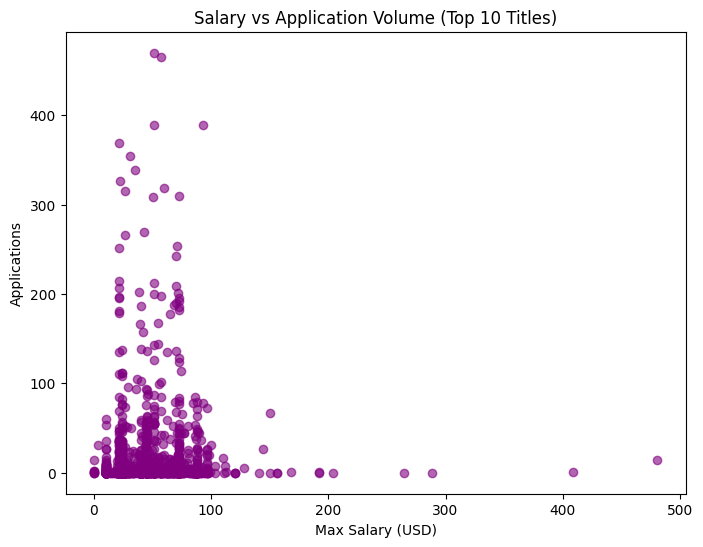

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(df_top['normalized_salary_hourly'], df_top['applies'], alpha=0.6, color='purple')
plt.title("Salary vs Application Volume (Top 10 Titles)")
plt.xlabel("Max Salary (USD)")
plt.ylabel("Applications")
plt.show()

#### Reflection: Salary vs Application Volume

This scatter plot shows the relationship between salary and application volume across top 10 job titles.  
Key insights:
- Most applications cluster around jobs **below $100/hour**, suggesting higher interest in mid-range roles.
- As salary increases, application volume tends to drop, possibly due to stricter qualifications.
- The spread shows **no strong linear correlation**, indicating that salary alone doesn't drive application volume.

This visualization helps assess whether higher pay translates into more applicants and reveals that it doesn’t.

---

---

## 5. Final Reflection

### 5.1 Final Insight

**Question:** How do salary, application volume, and job visibility vary across the top 10 most-applied job titles and how do they influence each other?

#### Salary
- Tech jobs like Software Engineer and Data Engineer pay the most.  
- Senior roles (Executive, Director) also have high salaries.  
- Entry-level and support jobs pay less.

#### Applications
- Data Analyst gets the most applications, followed by Software Engineer.  
- Lower-paying or high skilled jobs attract fewer applicants.

#### Views vs Applications
- Jobs are viewed more than applied to.  
- High-paying jobs get attention but fewer applications, likely due to strict requirements.

#### Salary vs Applications
- Higher pay doesn’t always mean more applications.  
- Mid-range jobs get the most applicants because they’re more accessible.


#### Overall Insight
Salary, visibility, and job type all shape applicant behavior, but the relationship is **complex and non-linear**:
- High pay attracts attention but not always applications.  
- Mid-range roles generate the most applications because they are accessible by skill but still can earn generous ammount.  
- Visibility highlights interest, but application depends on how approachable the role feels.  

Together, these findings suggest that **companies must balance competitive pay, clear job descriptions, and realistic requirements** to attract the right talent. For students and early-career professionals, the data shows that **analyst and mid-level technical roles are strong entry points**, while long-term growth lies in advancing toward specialized engineering or leadership positions.

### 5.2 Suggestions for Alex

- **Skill Focus**  
  Technical roles (Software Engineer, Data Engineer) are high-paying and in demand.  
  Build strong coding, data engineering, and analytics skills.

- **Career Entry Points**  
  Data Analyst attracts the most applications, making it competitive but still accessible.  
  Target analyst positions as a practical entry point before moving into higher-paying engineering roles.

- **Experience Awareness**  
  Salaries grow with experience (Associate → Mid-Senior → Executive).  
  Starting with internships or entry-level roles, then upskill toward senior positions.

- **Application Strategy**  
  Many candidates view jobs but don’t apply.  
  Be proactive: apply even when unsure.

- **Learning Investment**  
  Mid-range salaries attract more applicants because they’re accessible.  
  Balance ambition with realistic goals, using internships and projects to build credibility.

---